In [10]:
import tables
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Load reference HESE12 dataset
REF_PATH = '/data/ana/Diffuse/GlobalFit_Flavor/taupede/data/Pass2/hdf_files/NoDeepCore/HESE12/Bfr/HESE12.hdf5'

with tables.open_file(REF_PATH, 'r') as f:
    df_hdr = pd.DataFrame({
        'run':   f.root.I3EventHeader.col('Run'),
        'event': f.root.I3EventHeader.col('Event'),
    })
    df_en = pd.DataFrame({
        'run':         f.root.RecoETot.col('Run'),
        'event':       f.root.RecoETot.col('Event'),
        'reco_energy': f.root.RecoETot.col('value'),
    })
    df_zen = pd.DataFrame({
        'run':          f.root.RecoZenith.col('Run'),
        'event':        f.root.RecoZenith.col('Event'),
        'reco_zenith':  f.root.RecoZenith.col('value'),
    })

df_ref = df_hdr.merge(df_en, on=['run', 'event'], how='left')
df_ref = df_ref.merge(df_zen, on=['run', 'event'], how='left')
df_ref['log10_energy'] = np.log10(df_ref['reco_energy'])
df_ref['cos_zenith']   = np.cos(df_ref['reco_zenith'])
print(f'Reference HESE12: {len(df_ref)} events')
df_ref.head()

Reference HESE12: 97 events


,run,event,reco_energy,reco_zenith,log10_energy,cos_zenith
0,134912,80902176,106029.802180,1.491527,5.025428,0.079186
1,131502,58093123,401730.596192,1.523708,5.603935,0.047071
2,131505,52347097,150473.232499,0.932356,5.177459,0.595944
3,129253,4711217,259569.685977,0.833232,5.414254,0.672487
4,128619,66564632,151213.222561,1.151748,5.179590,0.406891


In [11]:
BASE_PATH = '/data/user/tvaneede/GlobalFit/reco_processing/data/hese/output/{version}'

DATASETS = [
    'IC79_2010', 'IC86_2011', 'IC86_2012', 'IC86_2013', 'IC86_2014',
    'IC86_2015', 'IC86_2016', 'IC86_2017', 'IC86_2018', 'IC86_2019',
    'IC86_2020', 'IC86_2021', 'IC86_2022',
]

def load_evtgen(version):
    records = []
    for dataset in DATASETS:
        path = Path(BASE_PATH.format(version=version)) / dataset / 'EvtGen' / 'EvtGen.h5'
        if not path.exists():
            print(f'  {dataset}: MISSING')
            continue
        with tables.open_file(str(path), 'r') as f:
            df_hdr = pd.DataFrame({
                'run':   f.root.I3EventHeader.col('Run'),
                'event': f.root.I3EventHeader.col('Event'),
            })
            df_en = pd.DataFrame({
                'run':         f.root.RecoETot.col('Run'),
                'event':       f.root.RecoETot.col('Event'),
                'reco_energy': f.root.RecoETot.col('value'),
            })
            df_zen = pd.DataFrame({
                'run':         f.root.RecoZenith.col('Run'),
                'event':       f.root.RecoZenith.col('Event'),
                'reco_zenith': f.root.RecoZenith.col('value'),
            })
            if hasattr(f.root, 'HESE_CausalQTot'):
                df_qtot = pd.DataFrame({
                    'run':              f.root.HESE_CausalQTot.col('Run'),
                    'event':            f.root.HESE_CausalQTot.col('Event'),
                    'hese_causal_qtot': f.root.HESE_CausalQTot.col('value'),
                })
            else:
                df_qtot = None
        df = df_hdr.merge(df_en,  on=['run', 'event'], how='left')
        df = df.merge(df_zen, on=['run', 'event'], how='left')
        if df_qtot is not None:
            df = df.merge(df_qtot, on=['run', 'event'], how='left')
        df.insert(0, 'dataset', dataset)
        records.append(df)
        print(f'  {dataset}: {len(df)} events')
    result = pd.concat(records, ignore_index=True)
    result['log10_energy'] = np.log10(result['reco_energy'])
    result['cos_zenith']   = np.cos(result['reco_zenith'])
    print(f'  Total: {len(result)}')
    return result

print('Loading v2...')
df_v2 = load_evtgen('v2')

# applying energy cut
df_v2 = df_v2[ df_v2["reco_energy"] > 60e3 ]

Loading v2...
  IC79_2010: 7 events
  IC86_2011: 21 events
  IC86_2012: 9 events
  IC86_2013: 16 events
  IC86_2014: 15 events
  IC86_2015: 9 events
  IC86_2016: 22 events
  IC86_2017: 18 events
  IC86_2018: 16 events
  IC86_2019: 19 events
  IC86_2020: 10 events
  IC86_2021: 12 events
  IC86_2022: 19 events
  Total: 193


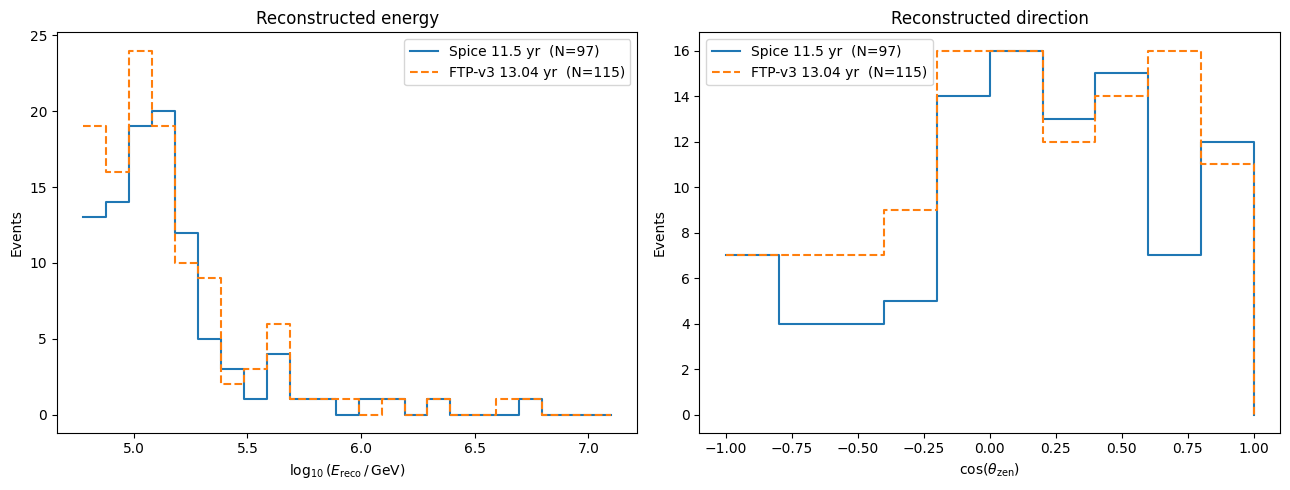

In [12]:
# Binning
energy_edges = np.linspace(4.778, 7.1, 24)   # 24 bins in log10(E/GeV)
zenith_edges  = np.linspace(-1, 1, 11)         # 11 bins in cos(zenith)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Energy histogram ---
ax = axes[0]
for df, label, color, ls in [
    (df_ref, 'Spice 11.5 yr', 'C0', '-'),
    (df_v2,  'FTP-v3 13.04 yr','C1', '--'),
]:
    vals = df['log10_energy'].dropna().values
    h, _ = np.histogram(vals, bins=energy_edges)
    ax.step(energy_edges, np.append(h, 0), where='post', color=color, ls=ls,
            label=f'{label}  (N={h.sum()})')

ax.set_xlabel(r'$\log_{10}(E_{\rm reco}\,/\,{\rm GeV})$')
ax.set_ylabel('Events')
ax.set_title('Reconstructed energy')
ax.legend()

# --- Zenith histogram ---
ax = axes[1]
for df, label, color, ls in [
    (df_ref, 'Spice 11.5 yr', 'C0', '-'),
    (df_v2,  'FTP-v3 13.04 yr','C1', '--'),
]:
    vals = df['cos_zenith'].dropna().values
    h, _ = np.histogram(vals, bins=zenith_edges)
    ax.step(zenith_edges, np.append(h, 0), where='post', color=color, ls=ls,
            label=f'{label}  (N={h.sum()})')

ax.set_xlabel(r'$\cos(\theta_{\rm zen})$')
ax.set_ylabel('Events')
ax.set_title('Reconstructed direction')
ax.legend()

fig.tight_layout()
plt.show()

In [9]:
zenith_edges

array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ])